In [2]:
import pandas as pd

df = pd.read_csv("mini_project.csv")
print(df.columns)

Index(['header', 'title', 'titleUrl', 'description', 'time', 'products',
       'details', 'activityControls', 'subtitles'],
      dtype='object')


In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("mini_project.csv")

# Correct timestamp parsing (Google Takeout safe)
df['timestamp'] = pd.to_datetime(df['time'], format='mixed', utc=True)

df['hour'] = df['timestamp'].dt.hour
df['date'] = df['timestamp'].dt.date
df['weekday'] = df['timestamp'].dt.weekday

# Behaviour flags
df['late_night'] = df['hour'].between(0,5)
df['is_weekend'] = df['weekday'] >= 5
df['is_short'] = df['titleUrl'].str.contains('shorts', na=False)

# Session detection (30 min gap)
df = df.sort_values('timestamp')
df['time_diff'] = df['timestamp'].diff().dt.total_seconds() / 60
df['new_session'] = (df['time_diff'] > 30) | (df['time_diff'].isna())
df['session_id'] = df['new_session'].cumsum()

# Category extraction
df['category'] = df['details'].astype(str).str.extract(r'category":"(.*?)"')

# Feature table (single user)
features = pd.DataFrame({
    'avg_daily_watch_count': [df.groupby('date').size().mean()],
    'late_night_ratio': [df['late_night'].mean()],
    'weekend_ratio': [df['is_weekend'].mean()],
    'shorts_ratio': [df['is_short'].mean()],
    'sessions_per_day': [df.groupby('date')['session_id'].nunique().mean()],
    'binge_session_length': [df.groupby('session_id').size().max()],
    'category_entropy': [-(df['category'].value_counts(normalize=True)
                           * np.log(df['category'].value_counts(normalize=True))).sum()]
})

features.to_csv("youtube_features.csv", index=False)
print(features)


   avg_daily_watch_count  late_night_ratio  weekend_ratio  shorts_ratio  \
0              73.312402          0.154154       0.331542           0.0   

   sessions_per_day  binge_session_length  category_entropy  
0          3.982732                   423              -0.0  


In [5]:
##Create synthetic multi-user dataset:
synthetic = pd.concat([features]*50, ignore_index=True)
synthetic += np.random.normal(0, 0.05, synthetic.shape)
synthetic.to_csv("multi_user_youtube_features.csv", index=False)


In [8]:
##STEP 1: Load & Prepare Data (Mandatory)
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("multi_user_youtube_features.csv")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)


C:\Users\Nithin naik\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Nithin naik\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Nithin naik\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Nithin naik\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have

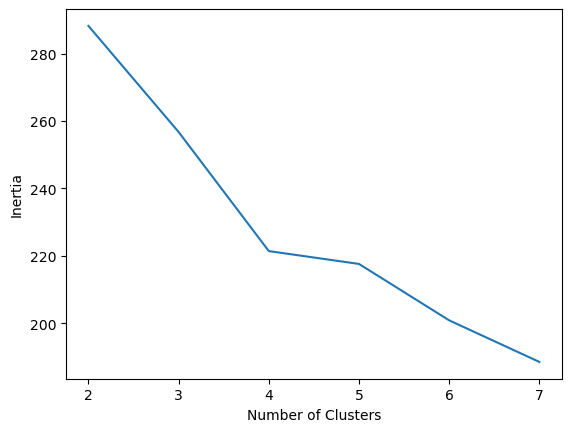

In [9]:
##STEP 2: Find Optimal Number of Clusters
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(2,8), inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()


In [10]:
##STEP 3: Apply Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

C:\Users\Nithin naik\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [11]:
## STEP 4: Interpret Clusters
cluster_summary = df.groupby('cluster').mean()
print(cluster_summary)

         avg_daily_watch_count  late_night_ratio  weekend_ratio  shorts_ratio  \
cluster                                                                         
0                    73.287648          0.121756       0.286537     -0.026840   
1                    73.326412          0.182089       0.346628      0.003026   
2                    73.266720          0.126244       0.397370     -0.006386   
3                    73.344765          0.131955       0.332078      0.048450   

         sessions_per_day  binge_session_length  category_entropy  
cluster                                                            
0                3.967979            423.008583          0.019971  
1                4.020881            423.044537         -0.021179  
2                4.036626            422.956735         -0.028193  
3                3.966477            422.972501          0.040133  


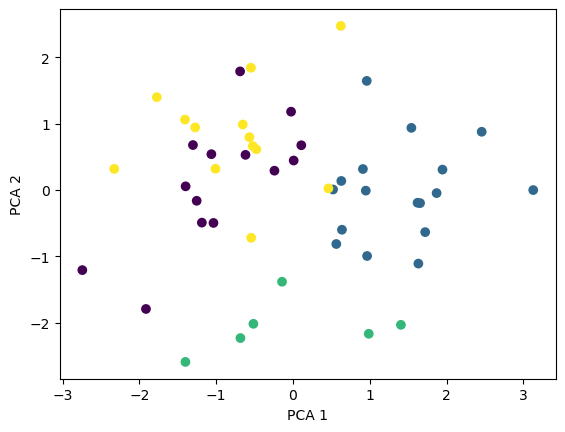

In [12]:
## STEP 5: Visualize Clusters
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


In [13]:
## STEP 6: Generate Final Outputs

df.to_csv("clustered_youtube_users.csv", index=False)

In [14]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv("clustered_youtube_users.csv")

risk_features = [
    'late_night_ratio',
    'shorts_ratio',
    'binge_session_length',
    'sessions_per_day',
    'weekend_ratio'
]

scaler = MinMaxScaler()
df[risk_features] = scaler.fit_transform(df[risk_features])

df['addiction_risk_score'] = (
    0.30 * df['late_night_ratio'] +
    0.25 * df['shorts_ratio'] +
    0.20 * df['binge_session_length'] +
    0.15 * df['sessions_per_day'] +
    0.10 * df['weekend_ratio']
) * 100

df.to_csv("youtube_users_with_risk.csv", index=False)


In [15]:
from sklearn.ensemble import IsolationForest

iso_features = [
    'addiction_risk_score',
    'late_night_ratio',
    'binge_session_length',
    'sessions_per_day'
]

iso = IsolationForest(contamination=0.1, random_state=42)
df['anomaly'] = iso.fit_predict(df[iso_features])

df['anomaly_label'] = df['anomaly'].map({
    1: 'Normal User',
    -1: 'Extreme Addict'
})

df.to_csv("youtube_users_final.csv", index=False)

print(df['anomaly_label'].value_counts())


anomaly_label
Normal User       45
Extreme Addict     5
Name: count, dtype: int64
